# Available MCDA Methods in VISTA

This notebook provides an overview of **all 16 built-in MCDA methods** in *mcda-vista*.
We explore the method registry, generate baseline VISTA maps with default parameters,
and compare methods within their natural families.

> **Notebook 2 of 10** — see also:
> - *01 — Quick Start*
> - *03 — Parameter Exploration*
> - *06 — Custom Methods*

## 1. Setup

In [1]:
%matplotlib inline

from mcda_vista import generate_vista, plot_vista, plot_vista_comparison, VistaResult
from mcda_vista.methods import list_methods, get_method

## 2. List All Methods

`list_methods()` returns sorted names of every registered method.
For each one we can retrieve a `MethodAdapter` that exposes
`.display_name` and `.default_params()`.

In [2]:
method_names = list_methods()
print(f"Total methods: {len(method_names)}\n")

for name in method_names:
    adapter = get_method(name)
    params = adapter.default_params()
    params_str = ", ".join(f"{k}={v!r}" for k, v in params.items()) if params else "(none)"
    print(f"  {adapter.display_name:<18s} [{name}]  —  {params_str}")

Total methods: 16

  ASSESS             [assess]  —  k=5, form='L', delta=0.1
  Borda              [borda]  —  (none)
  ELECTRE III        [electre_iii]  —  q=0.1, p=0.2, v=1.0, alpha=-0.15, beta=0.3
  ELECTRE IIIc       [electre_iiic]  —  q=0.1, p=0.2, v=1.0, lamb=0.6
  E-TOPSIS           [etopsis]  —  aggregation='R', epsilon=1.0, delta=0.1
  MACBETH            [macbeth]  —  delta=0.1
  ORESTE             [oreste]  —  alpha=0.4
  PROMETHEE I        [promethee_i]  —  f='t4', q=0.1, p=0.2, s=0.0
  PROMETHEE II       [promethee_ii]  —  f='t4', q=0.1, p=0.2, s=0.0, delta=0.1
  PROMETHEE III      [promethee_iii]  —  f='t4', q=0.1, p=0.2, s=0.0, lmbd=0.1
  REGIME             [regime]  —  (none)
  SAW                [saw]  —  delta=0.1
  SPOTIS             [spotis]  —  delta=0.1
  TOPSIS             [topsis]  —  delta=0.1
  UTA                [uta]  —  k=5, form='L', delta=0.1
  VIKOR              [vikor]  —  v=0.5


D:\Praca\Uczelnia\Praca naukowa\Github\vista\mcda-vista\src\mcda_vista\methods\_patches.py:383: UserWarning: Could not detect pyDecision version; VISTA patches may not apply correctly.
  apply_patches()


## 3. Generate Baseline VISTA Maps for All Methods

We use `resolution=51` (51 × 51 = 2 601 grid points) for fast generation
while still producing clear maps. Every method runs with its own default parameters.

In [3]:
RESOLUTION = 51

results = []
for i, name in enumerate(method_names, 1):
    adapter = get_method(name)
    print(f"[{i:2d}/{len(method_names)}] Generating {adapter.display_name} ...", end=" ")
    result = generate_vista(name, resolution=RESOLUTION, progress=False, **adapter.default_params())
    results.append(result)
    elapsed = result.metadata.get("elapsed_seconds", 0)
    print(f"done ({elapsed:.1f}s)")

print(f"\nAll {len(results)} methods generated.")

[ 1/16] Generating ASSESS ... done (0.0s)
[ 2/16] Generating Borda ... done (0.1s)
[ 3/16] Generating ELECTRE III ... 

done (0.7s)
[ 4/16] Generating ELECTRE IIIc ... 

done (1.0s)
[ 5/16] Generating E-TOPSIS ... 

done (0.3s)
[ 6/16] Generating MACBETH ... done (0.1s)
[ 7/16] Generating ORESTE ... 

done (0.9s)
[ 8/16] Generating PROMETHEE I ... done (0.1s)
[ 9/16] Generating PROMETHEE II ... 

done (0.1s)
[10/16] Generating PROMETHEE III ... done (0.1s)
[11/16] Generating REGIME ... done (0.1s)
[12/16] Generating SAW ... 

done (0.1s)
[13/16] Generating SPOTIS ... done (0.1s)
[14/16] Generating TOPSIS ... done (0.1s)
[15/16] Generating UTA ... 

done (0.1s)
[16/16] Generating VIKOR ... 

done (0.3s)

All 16 methods generated.


## 4. Side-by-Side Comparison

The facet-wrap plot places every method on a single figure for easy visual comparison.
Each subplot is color-coded:

| Color | Relation |
|-------|----------|
| 🟢 Green | Better than reference |
| 🟡 Yellow | Indifferent to reference |
| 🔴 Red | Worse than reference |
| 🔵 Blue | Incomparable with reference |

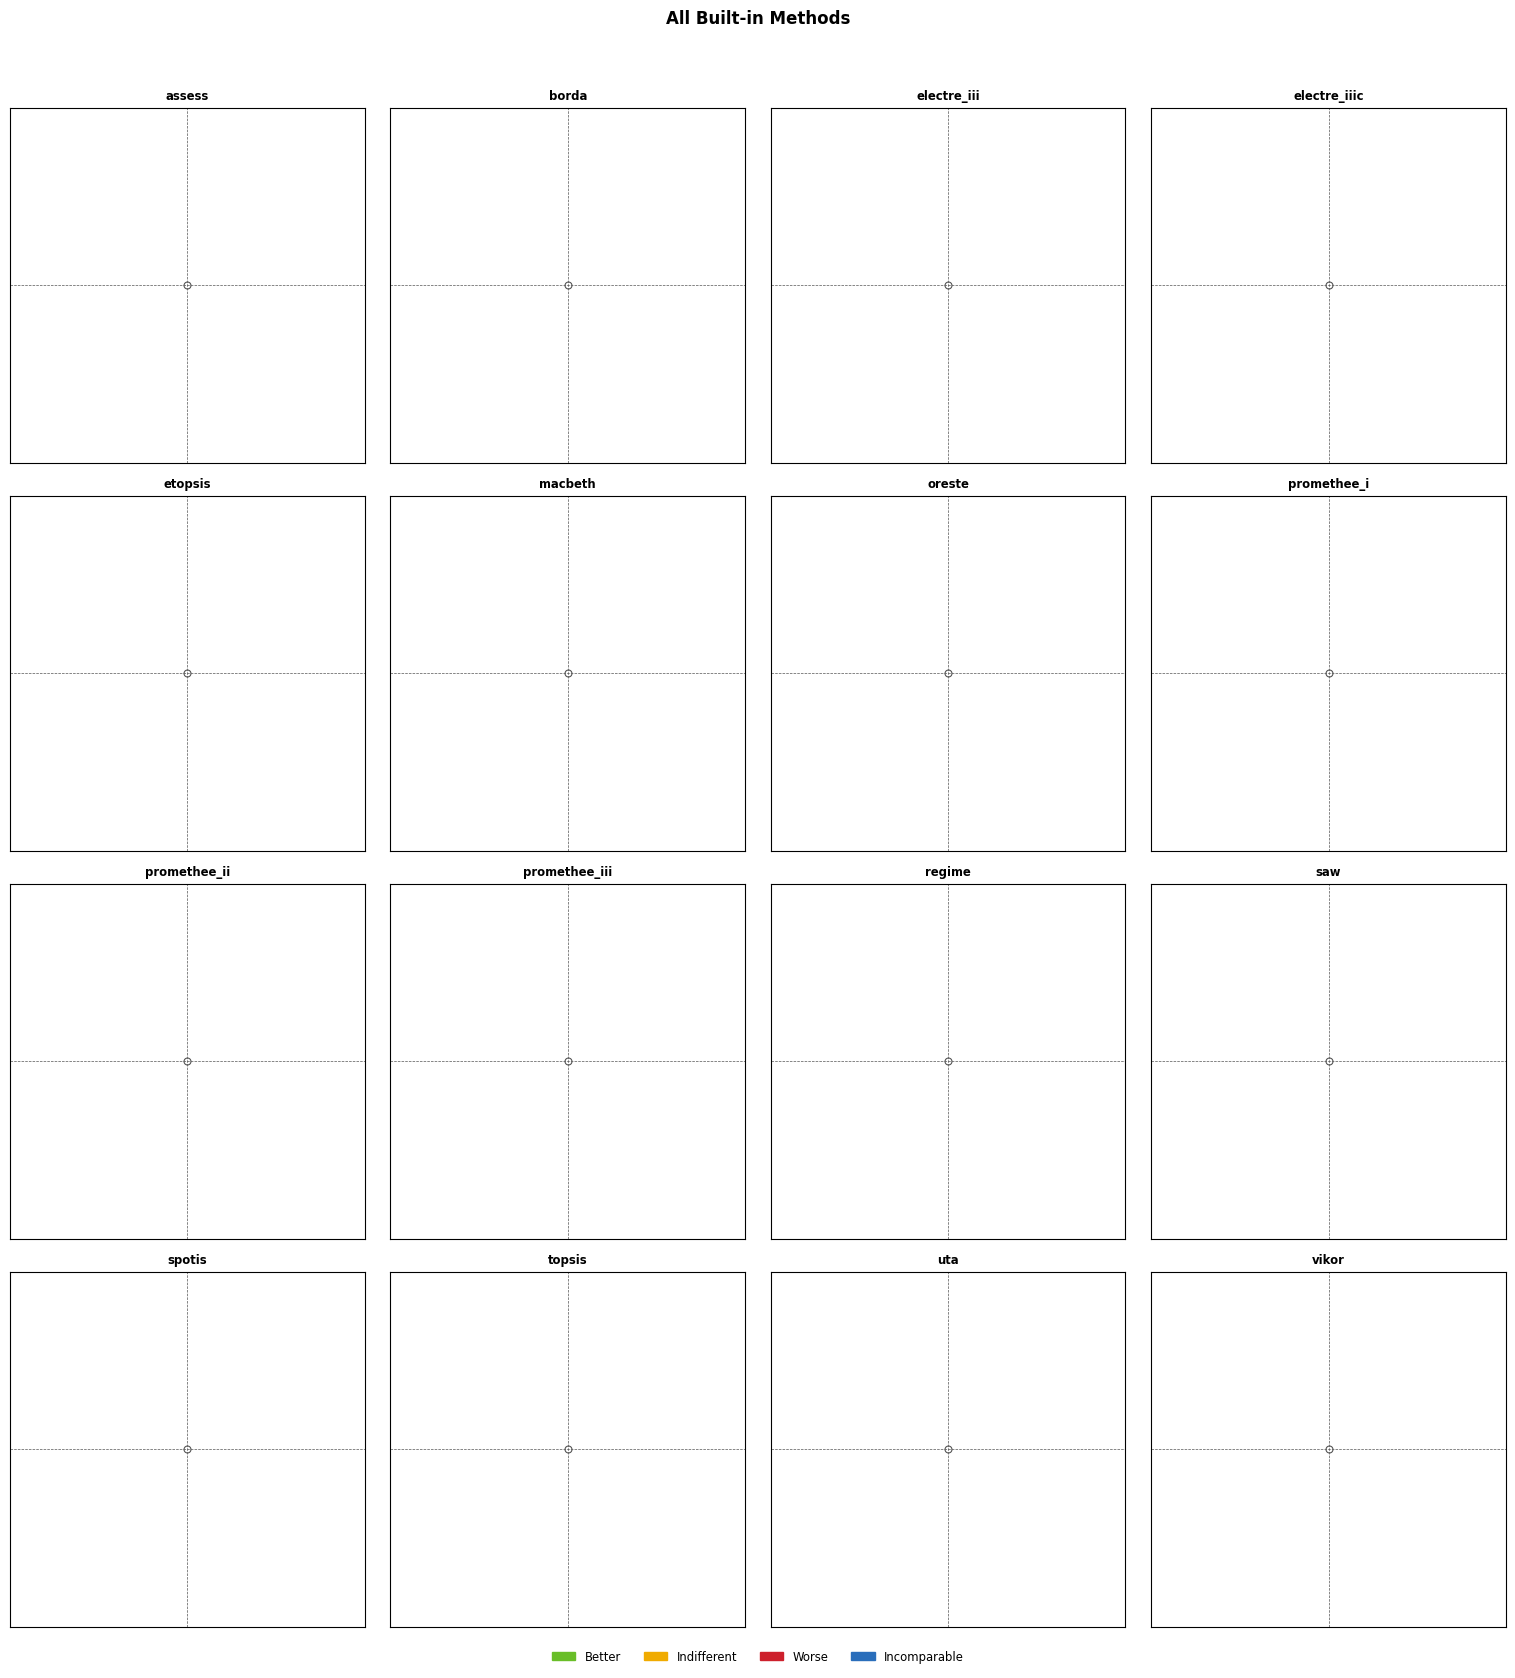

In [4]:
fig = plot_vista_comparison(results, ncols=4, title="All Built-in Methods")
fig.set_size_inches(16, 16)
fig.tight_layout()

## 5. Method Families

The 16 methods fall naturally into four families:

### Distance-based (SAW, TOPSIS, E-TOPSIS, SPOTIS)

These methods compare alternatives by computing a distance (or closeness coefficient)
relative to an ideal and/or anti-ideal solution. They produce **total orders** — every
alternative is either better, worse, or indifferent; there are no incomparable regions.

### Ranking-based (Borda, ORESTE, REGIME)

These methods derive ordinal rankings from pairwise or positional comparisons.
They also produce total orders. Borda uses positional voting, ORESTE projects
alternatives onto a preference axis, and REGIME uses pairwise dominance counts.

### Outranking (ELECTRE III, ELECTRE IIIc, PROMETHEE I, PROMETHEE II, PROMETHEE III)

Outranking methods build credibility or preference-flow relations using
indifference (*q*), preference (*p*), and veto (*v*) thresholds.
Some of these methods — ELECTRE III, ELECTRE IIIc, PROMETHEE I, PROMETHEE III —
can produce **incomparable** (blue) regions, meaning they define a partial order.

### Scoring / Utility (VIKOR, MACBETH, UTA, ASSESS)

These methods aggregate criterion evaluations into a single utility or
compromise score. VIKOR uses a compromise-programming approach, MACBETH
employs interval scales, and UTA/ASSESS infer additive value functions
via mathematical programming.

## 6. Comparing Families

Let's generate focused comparison plots for each family.

In [5]:
families = {
    "Distance-based": ["saw", "topsis", "etopsis", "spotis"],
    "Ranking-based": ["borda", "oreste", "regime"],
    "Outranking": ["electre_iii", "electre_iiic", "promethee_i", "promethee_ii", "promethee_iii"],
    "Scoring / Utility": ["vikor", "macbeth", "uta", "assess"],
}

# Build a lookup from method name to its already-computed result
result_map = {r.method_name: r for r in results}

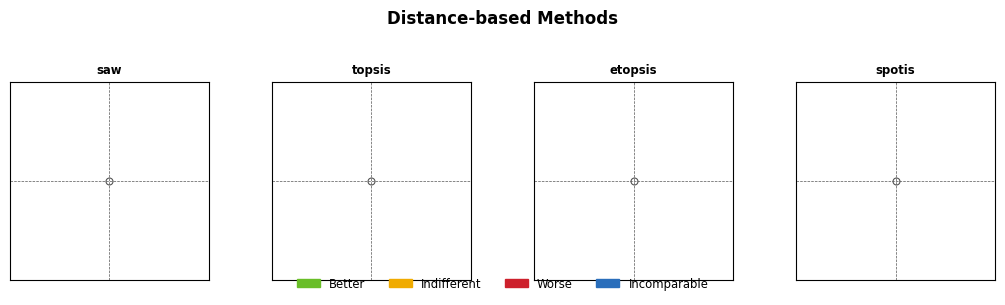

In [6]:
family_results = [result_map[m] for m in families["Distance-based"]]
fig = plot_vista_comparison(family_results, ncols=4, title="Distance-based Methods")
fig.tight_layout()

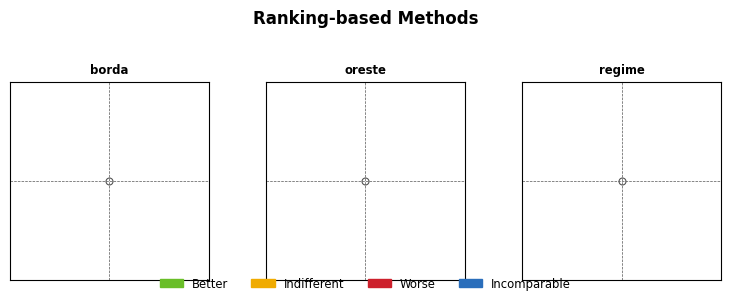

In [7]:
family_results = [result_map[m] for m in families["Ranking-based"]]
fig = plot_vista_comparison(family_results, ncols=3, title="Ranking-based Methods")
fig.tight_layout()

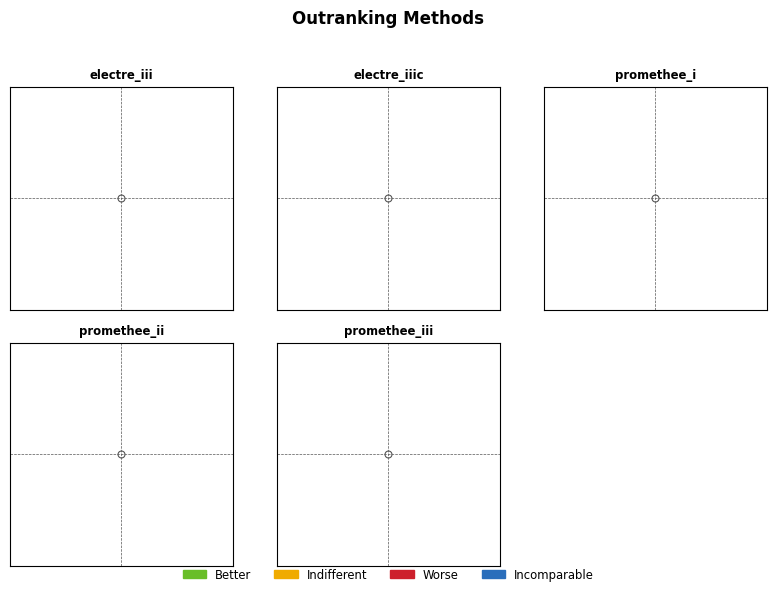

In [8]:
family_results = [result_map[m] for m in families["Outranking"]]
fig = plot_vista_comparison(family_results, ncols=3, title="Outranking Methods")
fig.tight_layout()

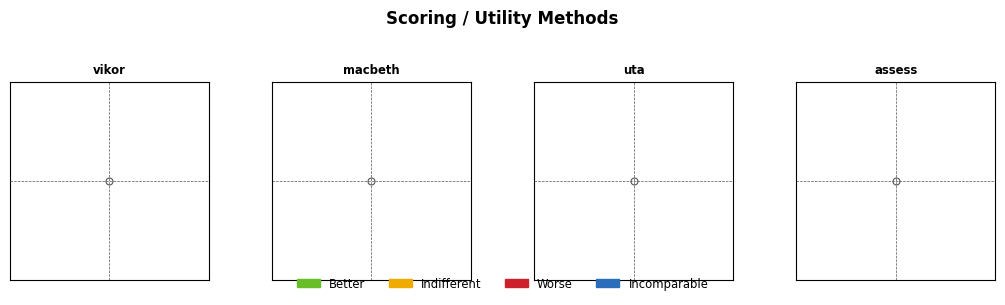

In [9]:
family_results = [result_map[m] for m in families["Scoring / Utility"]]
fig = plot_vista_comparison(family_results, ncols=4, title="Scoring / Utility Methods")
fig.tight_layout()

## 7. Methods with Incomparable Regions

Most MCDA methods produce a **total order** — every point on the VISTA map is
classified as better (green), worse (red), or indifferent (yellow).

However, four methods can produce **incomparable** (blue) regions, indicating
that the method cannot decide the relation between the test point and the reference:

| Method | Why incomparability arises |
|--------|---------------------------|
| ELECTRE III | Distillation-based ranking can leave alternatives unranked |
| ELECTRE IIIc | Credibility cut at λ may leave pairs unrelated |
| PROMETHEE I | Partial ranking from positive/negative flows |
| PROMETHEE III | Interval-based flows create indeterminacy zones |

Let's compare these four methods side by side.

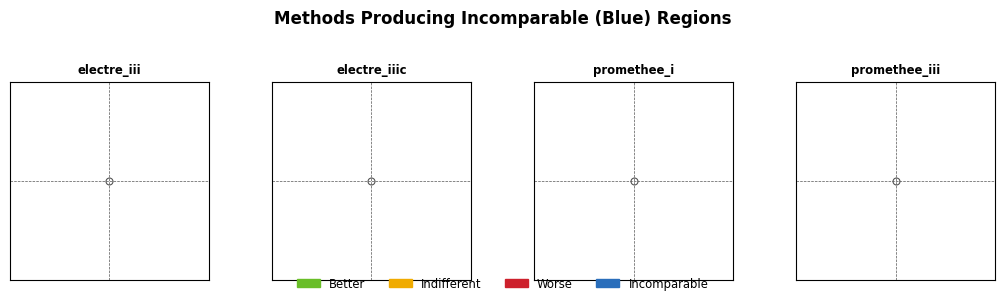

In [10]:
incomparable_methods = ["electre_iii", "electre_iiic", "promethee_i", "promethee_iii"]
incomp_results = [result_map[m] for m in incomparable_methods]

fig = plot_vista_comparison(
    incomp_results,
    ncols=4,
    title="Methods Producing Incomparable (Blue) Regions",
)
fig.tight_layout()

## 8. Next Steps

- **Notebook 03 — Parameter Exploration**: See how changing thresholds, weights,
  and other parameters reshapes the VISTA maps.
- **Notebook 06 — Custom Methods**: Learn how to register your own MCDA method
  with the VISTA framework.